# Gerchberg-Saxton phase retrieval

In this tutorial, we retrieve the phase of a laser pulse from measurements of the intensity at different planes. The number of planes should be greater than or equal to two. The phase retrieval can either be done using a modal decomposition or any propagator of choice. 

In [1]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import c, epsilon_0

from lasy.laser import Laser
from lasy.profiles import CombinedLongitudinalTransverseProfile
from lasy.profiles.longitudinal import ContinuousWaveProfile
from lasy.profiles.transverse import GaussianTransverseProfile
from lasy.utils.mode_decomposition import (
    hermite_gauss_composition,
    hermite_gauss_decomposition,
)
from lasy.utils.phase_retrieval import GerchbergSaxton

Next, we define the beam to be CW with a Gaussian profile in the transverse plane:

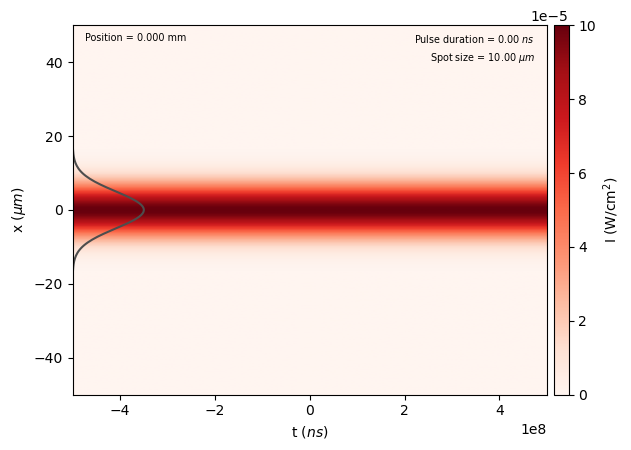

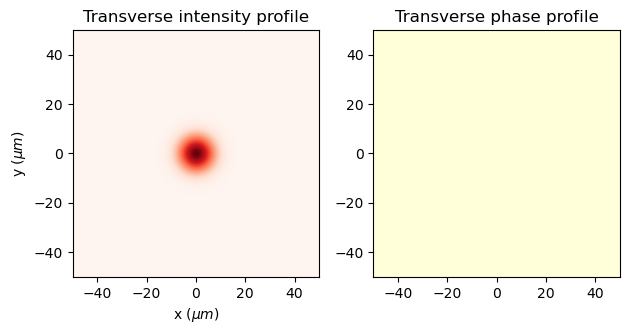

In [2]:
peak_fluence = 1.0  # J/m^2
spot_size = 10e-6
wavelength = 800e-9
omega0 = 2 * np.pi * c / wavelength
pol = (1, 0)

dimensions = "xyt"  # Use cylindrical geometry
lo = (-5.0 * spot_size, -5.0 * spot_size, None)  # Lower bounds of the simulation box
hi = (5.0 * spot_size, 5.0 * spot_size, None)  # Upper bounds of the simulation box
num_points = (256, 256, 1)  # Number of points in each dimension

long_prof = ContinuousWaveProfile(wavelength)
tran_prof = GaussianTransverseProfile(spot_size)
laser_profile = CombinedLongitudinalTransverseProfile(
    wavelength, pol, long_prof, tran_prof, peak_fluence=peak_fluence
)

laser = Laser(dimensions, lo, hi, num_points, laser_profile)

# Plot the xt laser profile
laser.show(envelope_type="intensity")  # In this case this is the fluence (CW beam)

# Plot the transverse laser profile
intensity = epsilon_0 * c / 2 * np.abs(laser.grid.get_temporal_field()) ** 2
fluence = np.sum(intensity, axis=-1).T * laser.grid.dx[-1]
phase = np.sum(np.angle(laser.grid.get_temporal_field()), axis=-1).T / (np.pi)
extent = (
    laser.grid.axes[0].min() * 1e6,
    laser.grid.axes[0].max() * 1e6,
    laser.grid.axes[1].min() * 1e6,
    laser.grid.axes[1].max() * 1e6,
)

fig, ax = plt.subplots(1, 2)
im = ax[0].imshow(fluence, aspect="equal", extent=extent, cmap="Reds")
ax[0].set_xlabel(r"x ($\mu m$)")
ax[0].set_ylabel(r"y ($\mu m$)")
ax[0].set_title("Transverse intensity profile")
# fig.colorbar(im, ax=ax[0], label=r"Fluence (J/m$^2$)", location='left', shrink=0.4)
ax[1].imshow(phase, extent=extent, cmap="YlGnBu")
ax[1].set_title("Transverse phase profile")
plt.tight_layout()
plt.show()

In [3]:
# Modal coefficients used to construct the beam
modes = {}
modes[(0, 0)] = 1 - 0.2j
modes[(0, 1)] = -0.4 - 0.2j
modes[(1, 0)] = 0.5 + 1j
modes[(2, 2)] = -0.05 + 0.1j

Using the mode coefficients above, we construct a higher-order Hermite-Gaussian laser pulse.

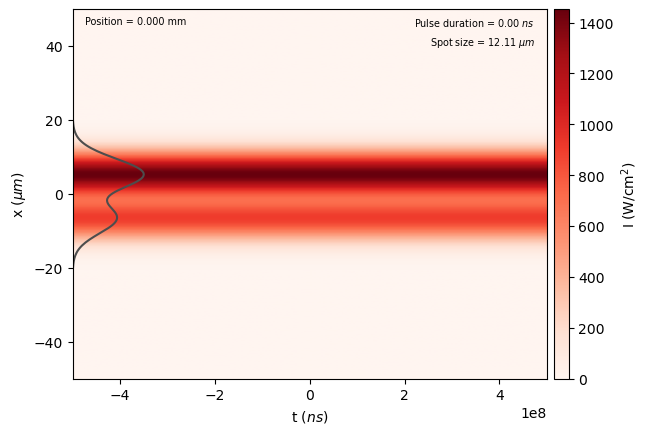

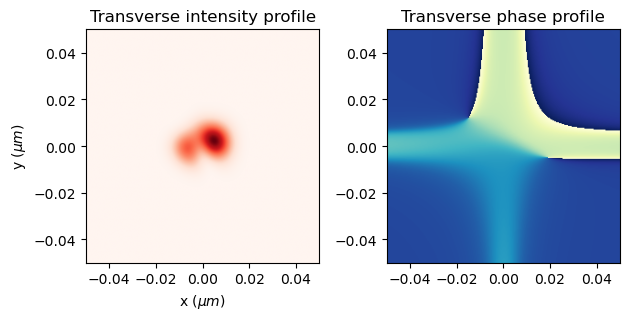

Mode coefficients for HG beam (up to third order)
0,0 :  1.00  ,  -0.20 i
0,1 :  -0.40  ,  -0.20 i
0,2 :  0.00  ,  0.00 i
1,0 :  0.50  ,  1.00 i
1,1 :  0.00  ,  0.00 i
1,2 :  0.00  ,  0.00 i
2,0 :  0.00  ,  -0.00 i
2,1 :  -0.00  ,  -0.00 i
2,2 :  -0.05  ,  0.10 i


In [4]:
HG_laser = deepcopy(laser)  # Make a copy of the input grid
hermite_gauss_composition(
    HG_laser, spot_size, spot_size, modes, skipAsymmetricModes=False
)

HG_laser.show(envelope_type="intensity")  # In this case this is the fluence (CW beam)

intensity = epsilon_0 * c / 2 * np.abs(HG_laser.grid.get_temporal_field()) ** 2
fluence = np.sum(intensity, axis=-1).T * HG_laser.grid.dx[-1]
extent = (
    HG_laser.grid.axes[0].min() * 1e3,
    HG_laser.grid.axes[0].max() * 1e3,
    HG_laser.grid.axes[1].min() * 1e3,
    HG_laser.grid.axes[1].max() * 1e3,
)

fig, ax = plt.subplots(1, 2)
im = ax[0].imshow(fluence, aspect="equal", extent=extent, cmap="Reds")
ax[0].set_xlabel(r"x ($\mu m$)")
ax[0].set_ylabel(r"y ($\mu m$)")
ax[0].set_title("Transverse intensity profile")
# fig.colorbar(im, ax=ax[0], label=r"Fluence (J/m$^2$)", location='left', shrink=0.4)
ax[1].imshow(
    np.angle(HG_laser.grid.get_temporal_field()) / (np.pi), extent=extent, cmap="YlGnBu"
)
ax[1].set_title("Transverse phase profile")
plt.tight_layout()
plt.show()

calculatedModes = hermite_gauss_decomposition(HG_laser, spot_size, spot_size, 3, 3)
print("Mode coefficients for HG beam (up to third order)")
for calcModeKey in calculatedModes.keys():
    print(
        "%i,%i :  %.2f  ,  %.2f i"
        % (
            calcModeKey[0],
            calcModeKey[1],
            np.real(calculatedModes[calcModeKey]),
            np.imag(calculatedModes[calcModeKey]),
        )
    )

We now construct the focal scan data by propagating the laser. This could alternatively be done by following the 'denoising laser' tutorial to convert transverse intensity data to a LASY laser object. The phase information is irrelevant and is randomly initialised when setting up the Gerchberg-Saxton.

In [5]:
zScan = 500e-6
plane = deepcopy(HG_laser)
field = [None] * 5

field[2] = deepcopy(plane)
plane.propagate(-2 * zScan)
field[0] = deepcopy(plane)
plane.propagate(zScan)
field[1] = deepcopy(plane)
plane.propagate(2 * zScan)
field[3] = deepcopy(plane)
plane.propagate(zScan)
field[4] = deepcopy(plane)

zVals = [-2 * zScan, -zScan, 0, zScan, 2 * zScan]

Available backends are: NP
NP is chosen


  0%|          | 00:00<? [?it/s]

  0%|          | 00:00<? [?it/s]

  0%|          | 00:00<? [?it/s]

  0%|          | 00:00<? [?it/s]

The Gerchberg-Saxton is initialised by passing a list of the laser objects for each plane and the corresponding axial positions relative to the focal plane.

Estimated w0(x-axis) = 10.65 microns (1/e^2 width)
Estimated w0(y-axis) = 14.25 microns (1/e^2 width)
0,0 :  1.39  ,  0.33 i
0,1 :  -0.18  ,  -0.06 i
0,2 :  -0.34  ,  0.08 i
1,0 :  0.12  ,  0.04 i
1,1 :  -0.14  ,  -0.08 i
1,2 :  -0.03  ,  0.02 i
2,0 :  0.24  ,  0.31 i
2,1 :  0.06  ,  0.01 i
2,2 :  -0.12  ,  -0.07 i


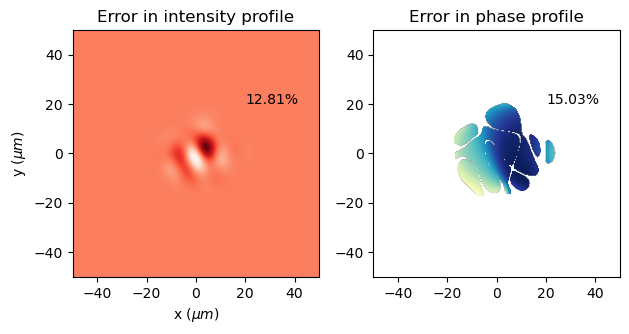

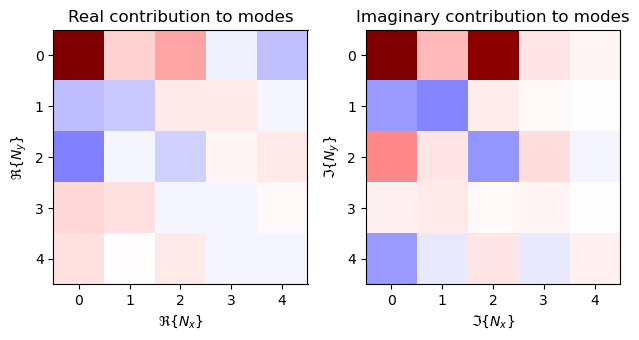

In [6]:
gs = GerchbergSaxton(field, zVals, m_max=5, n_max=5, max_iter=15, verbose=True)

i = 2  # Index of plane to check initial guess

# Plot the transverse laser profile
intensity = epsilon_0 * c / 2 * np.abs(HG_laser.grid.get_temporal_field()) ** 2
prof1 = np.sum(intensity, axis=-1).T * HG_laser.grid.dx[-1]
phase1 = np.sum(np.angle(HG_laser.grid.get_temporal_field()), axis=-1).T / (np.pi)

# Reconstructed profile
intensity = epsilon_0 * c / 2 * np.abs(gs.lasers[i].grid.get_temporal_field()) ** 2
prof2 = np.sum(intensity, axis=-1).T * gs.lasers[i].grid.dx[-1]
phase2 = np.sum(np.angle(gs.lasers[i].grid.get_temporal_field()), axis=-1).T / (np.pi)

# Normalized errors
prof_error = (prof1 - prof2) / np.max(prof1)
phase_error = (phase1 - phase2) / np.max(phase1)

masked_phase = np.ma.masked_where(
    np.abs(prof_error) < 0.01 * np.max(prof_error), phase_error
)  # The phase is only valid in regions of appreciable intensity

extent = (
    gs.lasers[i].grid.axes[0].min() * 1e6,
    gs.lasers[i].grid.axes[0].max() * 1e6,
    gs.lasers[i].grid.axes[1].min() * 1e6,
    gs.lasers[i].grid.axes[1].max() * 1e6,
)

fig, ax = plt.subplots(1, 2)
im = ax[0].imshow(prof_error, aspect="equal", extent=extent, cmap="Reds")
ax[0].set_xlabel(r"x ($\mu m$)")
ax[0].set_ylabel(r"y ($\mu m$)")
ax[0].set_title("Error in intensity profile")
ax[0].text(20, 20, "%.2f" % (np.max(prof_error) * 100) + "%")
ax[1].imshow(masked_phase, extent=extent, cmap="YlGnBu")
ax[1].text(20, 20, "%.2f" % (np.max(masked_phase) * 100) + "%")
ax[1].set_title("Error in phase profile")
plt.tight_layout()
plt.show()

# Plot mode contributions
calculatedModes = gs.modes
modesReal = np.zeros((gs.m_max, gs.n_max))
modesImag = np.zeros((gs.m_max, gs.n_max))
for i in range(gs.n_max):
    for j in range(gs.m_max):
        modesReal[i, j] = np.real(calculatedModes[(j, i)])
        modesImag[i, j] = np.imag(calculatedModes[(j, i)])

fig, ax = plt.subplots(1, 2)
extent = (gs.x.min() * 1e6, gs.x.max() * 1e6, gs.y.min() * 1e6, gs.y.max() * 1e6)
ax[0].imshow(
    modesReal,
    aspect="equal",
    cmap="seismic",
    vmin=-np.max(np.abs(modesReal)),
    vmax=np.max(np.abs(modesReal)),
)
ax[0].set_xlabel(r"$\Re\{N_x\}$")
ax[0].set_ylabel(r"$\Re\{N_y\}$")
ax[0].set_title("Real contribution to modes")
ax[1].imshow(
    modesImag,
    aspect="equal",
    cmap="seismic",
    vmin=-np.max(np.abs(modesImag)),
    vmax=np.max(np.abs(modesImag)),
)
ax[1].set_xlabel(r"$\Im\{N_x\}$")
ax[1].set_ylabel(r"$\Im\{N_y\}$")
ax[1].set_title("Imaginary contribution to modes")
plt.tight_layout()
plt.show()

### Perform the phase retrieval

In [7]:
chi2, chi2Grad = gs.retrieve_phase()

GSA Iteration: 0
    Image: 1 of 5
        Reconstruction: 0.228 s
        Decomposition:  0.231 s
    Image: 5 of 5
        Reconstruction: 0.224 s
        Decomposition:  0.230 s
    Image: 2 of 5
        Reconstruction: 0.225 s
        Decomposition:  0.230 s
    Image: 4 of 5
        Reconstruction: 0.224 s
        Decomposition:  0.230 s
    Image: 3 of 5
        Reconstruction: 0.168 s
        Decomposition:  0.173 s
GSA Iteration: 1
    Image: 1 of 5
        Reconstruction: 0.225 s
        Decomposition:  0.229 s
    Image: 5 of 5
        Reconstruction: 0.224 s
        Decomposition:  0.230 s
    Image: 2 of 5
        Reconstruction: 0.225 s
        Decomposition:  0.230 s
    Image: 4 of 5
        Reconstruction: 0.225 s
        Decomposition:  0.234 s
    Image: 3 of 5
        Reconstruction: 0.167 s
        Decomposition:  0.173 s
chi2     = 5.7200242e-05 
chi2Grad = 64.5342731 %
GSA Iteration: 2
    Image: 1 of 5
        Reconstruction: 0.224 s
        Decomposition:  0.229

We will now visualise the input and reconstructed fields. 

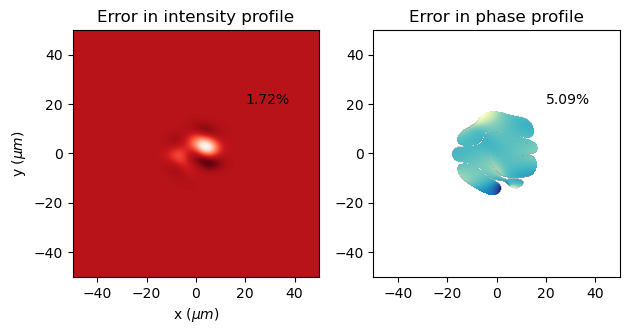

In [8]:
i = 2  # Index of plane to check reconstruction

# Plot the transverse laser profile
intensity = epsilon_0 * c / 2 * np.abs(HG_laser.grid.get_temporal_field()) ** 2
prof1 = np.sum(intensity, axis=-1).T * HG_laser.grid.dx[-1]
phase1 = np.sum(np.angle(HG_laser.grid.get_temporal_field()), axis=-1).T / (np.pi)

# Reconstructed profile
intensity = epsilon_0 * c / 2 * np.abs(gs.lasers[i].grid.get_temporal_field()) ** 2
prof2 = np.sum(intensity, axis=-1).T * gs.lasers[i].grid.dx[-1]
phase2 = np.sum(np.angle(gs.lasers[i].grid.get_temporal_field()), axis=-1).T / (np.pi)

# Normalized errors
prof_error_ = (prof1 - prof2) / np.max(prof1)
phase_error_ = (phase1 - phase2) / np.max(phase1)

masked_phase_ = np.ma.masked_where(
    np.abs(prof_error_) < 0.01 * np.max(prof_error_), phase_error_
)  # The phase is only valid in regions of appreciable intensity

extent = (
    gs.lasers[i].grid.axes[0].min() * 1e6,
    gs.lasers[i].grid.axes[0].max() * 1e6,
    gs.lasers[i].grid.axes[1].min() * 1e6,
    gs.lasers[i].grid.axes[1].max() * 1e6,
)

fig, ax = plt.subplots(1, 2)
im = ax[0].imshow(prof_error_, aspect="equal", extent=extent, cmap="Reds")
ax[0].set_xlabel(r"x ($\mu m$)")
ax[0].set_ylabel(r"y ($\mu m$)")
ax[0].set_title("Error in intensity profile")
ax[0].text(20, 20, "%.2f" % (np.max(prof_error_) * 100) + "%")
ax[1].imshow(
    masked_phase_, extent=extent, cmap="YlGnBu"
)  # Convolve with intensity to only show where
ax[1].text(20, 20, "%.2f" % (np.max(masked_phase_) * 100) + "%")
ax[1].set_title("Error in phase profile")
plt.tight_layout()
plt.show()

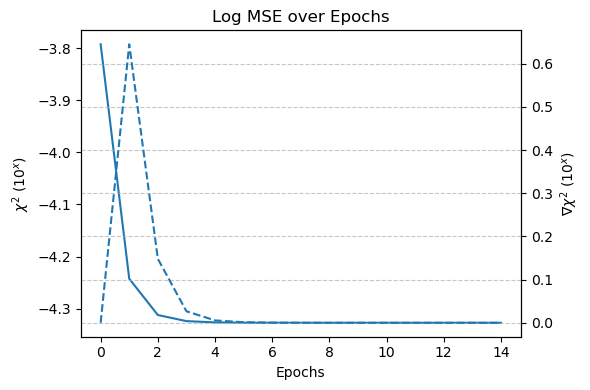

In [9]:
# Plot training and validation log MSE with 10^x format for the y-axis
def plot_log_mse(chi2, chi2Grad):
    """
    Plot the logarithm (base 10) of training and validation MSE losses with 10^x format for the y-axis.

    Parameters
    ----------
        train_losses (list): Training MSE values over epochs.
        val_losses (list): Validation MSE values over epochs.
    """
    fig, ax1 = plt.subplots(figsize=(6, 4))
    ax2 = ax1.twinx()
    log_chi2 = np.log10(chi2 + 1e-8)

    ax1.plot(range(len(chi2)), log_chi2)
    ax2.plot(range(len(chi2)), chi2Grad, "--")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(r"$\chi^2$ ($10^x$)")
    ax2.set_ylabel(r"$\nabla \chi^2$ ($10^x$)")
    plt.title("Log MSE over Epochs")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_log_mse(chi2, chi2Grad)